In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.11.0+cpu'

In [3]:
weight=0.3
bias=0.9
start=0
end=100
step=1
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias
X[:10],y[:10]

(tensor([[0],
         [1],
         [2],
         [3],
         [4],
         [5],
         [6],
         [7],
         [8],
         [9]]),
 tensor([[0.9000],
         [1.2000],
         [1.5000],
         [1.8000],
         [2.1000],
         [2.4000],
         [2.7000],
         [3.0000],
         [3.3000],
         [3.6000]]))

In [4]:
train_split=int(0.8 * len(X))
X_train, y_train=X[:train_split], y[:train_split]
X_test, y_test=X[train_split:], y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(80, 80, 20, 20)

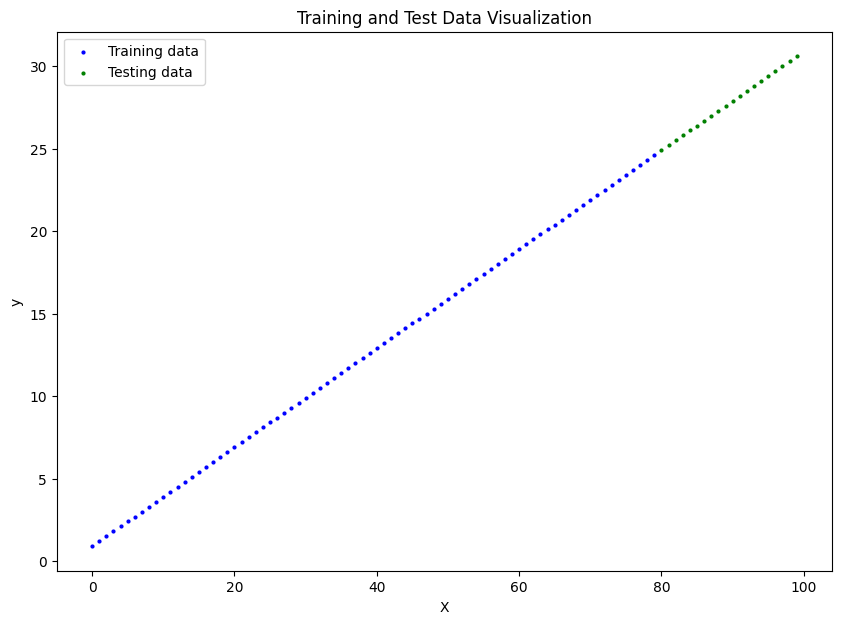

In [5]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c='b', s=4, label='Training data')
# Plot test data in green
plt.scatter(X_test, y_test, c='g', s=4, label='Testing data')
# Add labels and legend
plt.xlabel('X')
plt.ylabel('y')
plt.title('Training and Test Data Visualization')
plt.legend()
plt.show()

In [7]:
class ParaModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use the pre-initialized weight and bias values from the notebook's global scope
    self.weight = nn.Parameter(torch.tensor([[weight]]), requires_grad=True)
    self.bias = nn.Parameter(torch.tensor([bias]), requires_grad=True)

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    # Perform the linear transformation: y = weight * x + bias
    return self.weight * x + self.bias

torch.manual_seed(42)
model_1=ParaModelV2()
model_1,model_1.state_dict()

(ParaModelV2(),
 OrderedDict([('weight', tensor([[0.3000]])), ('bias', tensor([0.9000]))]))

In [10]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(model_1.parameters(),lr=0.01)

In [11]:
next(model_1.parameters()).device

device(type='cpu')

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_1.to(device) # the device variable was set above to be "cuda" if available or "cpu" if not
next(model_1.parameters()).device

device(type='cpu')

In [15]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 300

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train() # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval() # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.0 | Test loss: 0.0
Epoch: 20 | Train loss: 0.0 | Test loss: 0.0
Epoch: 40 | Train loss: 0.0 | Test loss: 0.0
Epoch: 60 | Train loss: 0.0 | Test loss: 0.0
Epoch: 80 | Train loss: 0.0 | Test loss: 0.0
Epoch: 100 | Train loss: 0.0 | Test loss: 0.0
Epoch: 120 | Train loss: 0.0 | Test loss: 0.0
Epoch: 140 | Train loss: 0.0 | Test loss: 0.0
Epoch: 160 | Train loss: 0.0 | Test loss: 0.0
Epoch: 180 | Train loss: 0.0 | Test loss: 0.0
Epoch: 200 | Train loss: 0.0 | Test loss: 0.0
Epoch: 220 | Train loss: 0.0 | Test loss: 0.0
Epoch: 240 | Train loss: 0.0 | Test loss: 0.0
Epoch: 260 | Train loss: 0.0 | Test loss: 0.0
Epoch: 280 | Train loss: 0.0 | Test loss: 0.0


In [16]:
print(model_1.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

OrderedDict({'weight': tensor([[0.3000]]), 'bias': tensor([0.9000])})

And the original values for weights and bias are:
weights: 0.3, bias: 0.9


In [17]:
model_1.eval()
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[24.9000],
        [25.2000],
        [25.5000],
        [25.8000],
        [26.1000],
        [26.4000],
        [26.7000],
        [27.0000],
        [27.3000],
        [27.6000],
        [27.9000],
        [28.2000],
        [28.5000],
        [28.8000],
        [29.1000],
        [29.4000],
        [29.7000],
        [30.0000],
        [30.3000],
        [30.6000]])

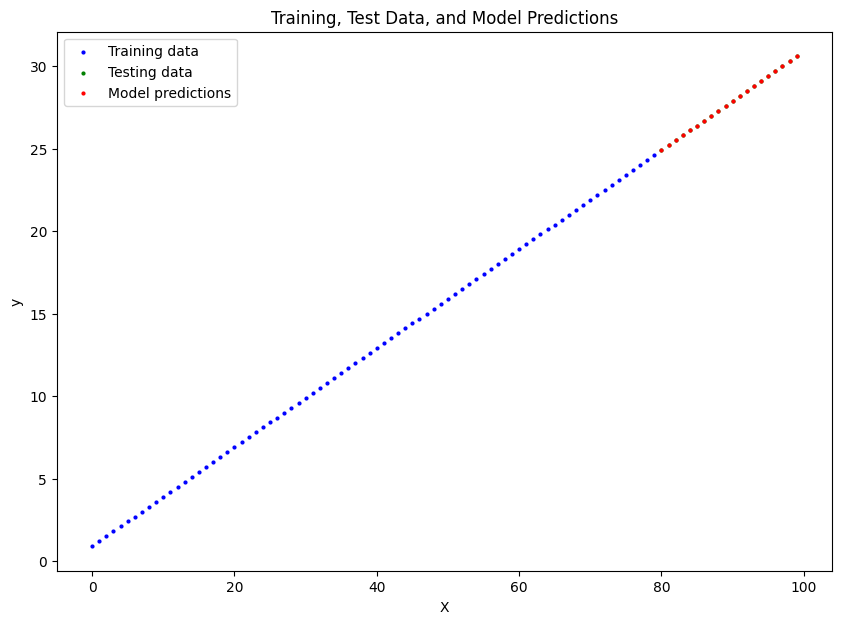

In [18]:
plt.figure(figsize=(10, 7))
# Plot training data
plt.scatter(X_train.cpu().numpy(), y_train.cpu().numpy(), c='b', s=4, label='Training data')
# Plot test data
plt.scatter(X_test.cpu().numpy(), y_test.cpu().numpy(), c='g', s=4, label='Testing data')
# Plot model's predictions on test data
plt.scatter(X_test.cpu().numpy(), y_preds.cpu().numpy(), c='r', s=4, label='Model predictions')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Training, Test Data, and Model Predictions')
plt.legend()
plt.show()

In [19]:
from pathlib import Path

MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME="01_pytorch_exercise_model_1.pth"
MODEL_SAVE_PATH=MODEL_PATH / MODEL_NAME
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_exercise_model_1.pth


In [20]:
model_2 = ParaModelV2()
model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
model_2.eval()
model_2

ParaModelV2()

In [21]:
model_2.eval()
with torch.inference_mode():
    y_preds_2 = model_2(X_test)

print(f"Predictions from original model (model_1):\n{y_preds}")
print(f"Predictions from loaded model (model_2):\n{y_preds_2}")

# Confirm they are the same
print(f"Do the predictions match? {torch.eq(y_preds, y_preds_2).all()}")

Predictions from original model (model_1):
tensor([[24.9000],
        [25.2000],
        [25.5000],
        [25.8000],
        [26.1000],
        [26.4000],
        [26.7000],
        [27.0000],
        [27.3000],
        [27.6000],
        [27.9000],
        [28.2000],
        [28.5000],
        [28.8000],
        [29.1000],
        [29.4000],
        [29.7000],
        [30.0000],
        [30.3000],
        [30.6000]])
Predictions from loaded model (model_2):
tensor([[24.9000],
        [25.2000],
        [25.5000],
        [25.8000],
        [26.1000],
        [26.4000],
        [26.7000],
        [27.0000],
        [27.3000],
        [27.6000],
        [27.9000],
        [28.2000],
        [28.5000],
        [28.8000],
        [29.1000],
        [29.4000],
        [29.7000],
        [30.0000],
        [30.3000],
        [30.6000]])
Do the predictions match? True
